# Initial Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 2* 0.0416667 # 1 hour to days

In [4]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

In [5]:
# List of known planet periods and epoch guesses (from paper)
known_planets = [
    {"name": "d", "period": 3.97664, "t0": 1357.8398},
    {"name": "e", "period": 7.90754, "t0": 1354.5659},
    {"name": "f", "period": 12.1621839, "t0": 1360.0754},
    {"name": "b", "period": 17.667087, "t0": 1360.6641},
    {"name": "c", "period":  29.79749, "t0":  1370.1037},
]


# Get data

In [6]:
TOI_id = 'TOI 174'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)


SearchResult containing 12 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   425997655      0.0
  1 TESS Sector 02 2018   SPOC     120   425997655      0.0
  2 TESS Sector 03 2018   SPOC     120   425997655      0.0
  3 TESS Sector 04 2018   SPOC     120   425997655      0.0
  4 TESS Sector 11 2019   SPOC     120   425997655      0.0
  5 TESS Sector 29 2020   SPOC     120   425997655      0.0
  6 TESS Sector 30 2020   SPOC     120   425997655      0.0
  7 TESS Sector 31 2020   SPOC     120   425997655      0.0
  8 TESS Sector 34 2021   SPOC     120   425997655      0.0
  9 TESS Sector 64 2023   SPOC     120   425997655      0.0
 10 TESS Sector 68 2023   SPOC     120   425997655      0.0
 11 TESS Sector 69 2023   SPOC     120   425997655      0.0


In [7]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 12 objects:
    0: <TessLightCurve LABEL="TIC 425997655" SECTOR=1 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 425997655" SECTOR=2 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 425997655" SECTOR=3 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 425997655" SECTOR=4 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 425997655" SECTOR=11 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 425997655" SECTOR=29 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 425997655" SECTOR=30 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 425997655" SECTOR=31 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 425997655" SECTOR=34 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 425997655" SECTOR=64 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 425997655" SE

In [8]:
clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [9]:
# Step 2: Normalize, flatten, and remove outliers
processed_lcs = [
    lc.normalize().flatten(window_length=401).remove_outliers(sigma=5)
    for lc in clean_lcs
]

In [10]:
# Step 3: Stitch into one combined light curve
combined_lc = processed_lcs[0]
for lc in processed_lcs[1:]:
    combined_lc = combined_lc.append(lc)



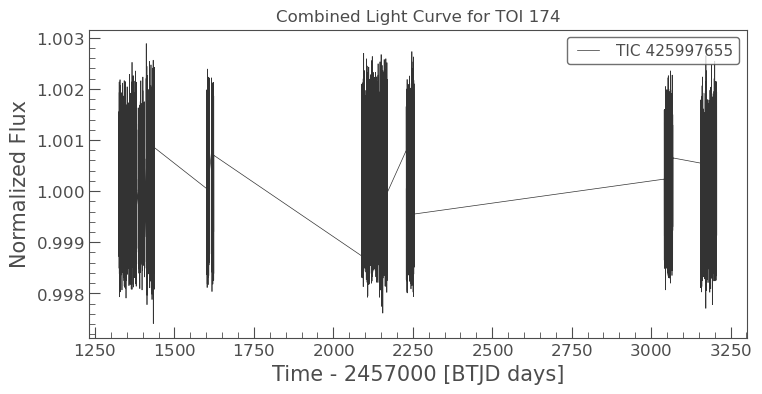

In [11]:
combined_lc.plot()
plt.title("Combined Light Curve for TOI 174")
plt.show()

In [12]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1325.29658484 1325.29797375 1325.29936267 ... 3206.30610315 3206.30749203
 3206.30888092]
[0.99978624 0.99906917 0.99895675 ... 0.99949611 1.00016749 1.00192988]


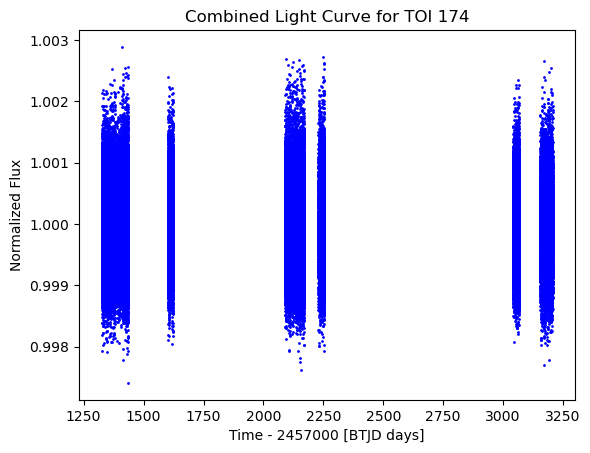

In [13]:
plt.scatter(time, flux, s=1, c='b')
plt.title('Combined Light Curve for TOI 174')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 279012 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


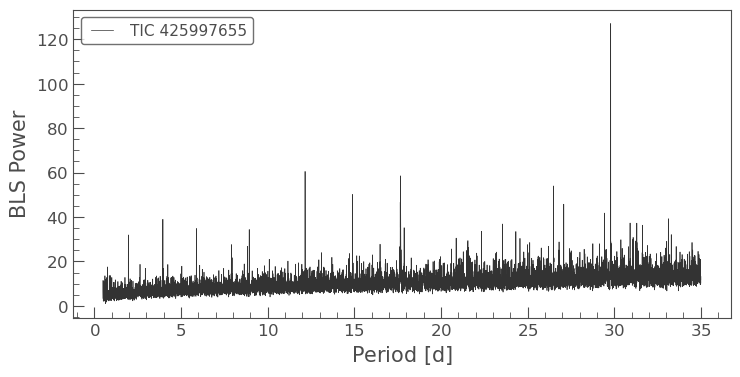

In [14]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(0.5, 35, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


`period` contains 279012 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


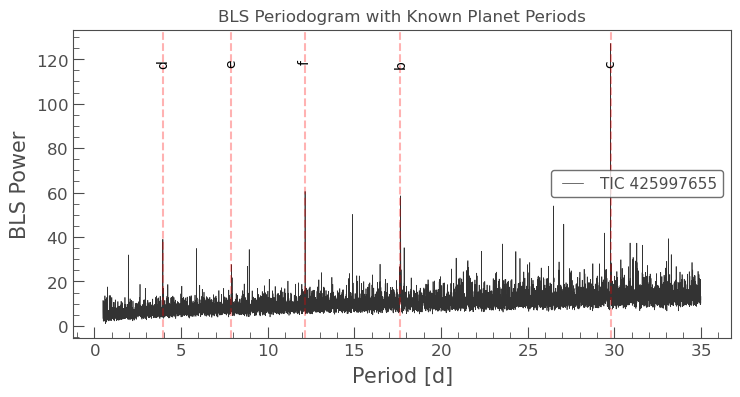

In [15]:
# BLS periodogram
bls_1 = combined_lc.to_periodogram(
    method='bls',
    period=np.linspace(0.5, 35, 10000),
    frequency_factor=500
)

# Plot the BLS periodogram
bls_1.plot()
plt.title("BLS Periodogram with Known Planet Periods")

# Overlay vertical lines at known periods
for planet in known_planets:
    plt.axvline(planet["period"], color='red', linestyle='--', alpha=0.3)
    plt.text(
        planet["period"], plt.ylim()[1]*0.9, f"{planet['name']}",
        rotation=90, color='black', fontsize=10, ha='center', va='top'
    )

plt.show()

In [16]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")

Best candidate period: 29.79688 days
Best candidate t0: 1340.31158 days


In [17]:
import numpy as np
from scipy.signal import find_peaks

# 1. Access full power array
powers = bls_1.power.value
periods = bls_1.period.value
durations = bls_1.duration.value
t0s = bls_1.transit_time.value

# 2. Find all peaks in the BLS power spectrum
peaks, _ = find_peaks(powers)

# 3. Sort peaks by power (descending)
sorted_peaks = peaks[np.argsort(powers[peaks])[::-1]]

# 4. Get top 3 signal indices
top_indices = sorted_peaks[:7]

# 5. Extract their periods, durations, and t0s
top_periods = periods[top_indices]
top_durations = durations[top_indices]
top_t0s = t0s[top_indices]
top_powers = powers[top_indices]

# 6. Print results
for i in range(7):
    print(f"Signal {i+1}:")
    print(f"  Period:   {top_periods[i]:.5f} days")
    print(f"  T0:       {top_t0s[i]:.5f}")
    print(f"  Duration: {top_durations[i]:.5f} days")
    print(f"  Power:    {top_powers[i]:.5f}")
    print("-" * 30)


Signal 1:
  Period:   29.79688 days
  T0:       1340.31158
  Duration: 0.10000 days
  Power:    127.06575
------------------------------
Signal 2:
  Period:   12.16217 days
  T0:       1335.75158
  Duration: 0.10000 days
  Power:    60.49311
------------------------------
Signal 3:
  Period:   17.66547 days
  T0:       1325.34658
  Duration: 0.10000 days
  Power:    58.49867
------------------------------
Signal 4:
  Period:   26.50180 days
  T0:       1334.14158
  Duration: 0.05000 days
  Power:    53.95869
------------------------------
Signal 5:
  Period:   14.89829 days
  T0:       1325.42658
  Duration: 0.05000 days
  Power:    50.13015
------------------------------
Signal 6:
  Period:   17.65512 days
  T0:       1325.36158
  Duration: 0.10000 days
  Power:    46.68250
------------------------------
Signal 7:
  Period:   27.08836 days
  T0:       1343.02158
  Duration: 0.10000 days
  Power:    45.74182
------------------------------


In [18]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

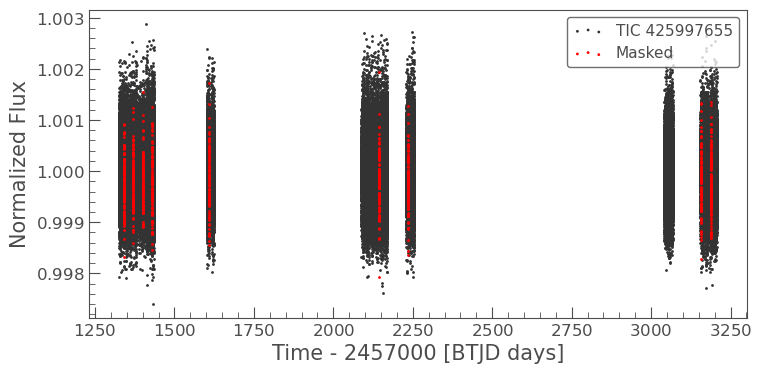

In [19]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [20]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


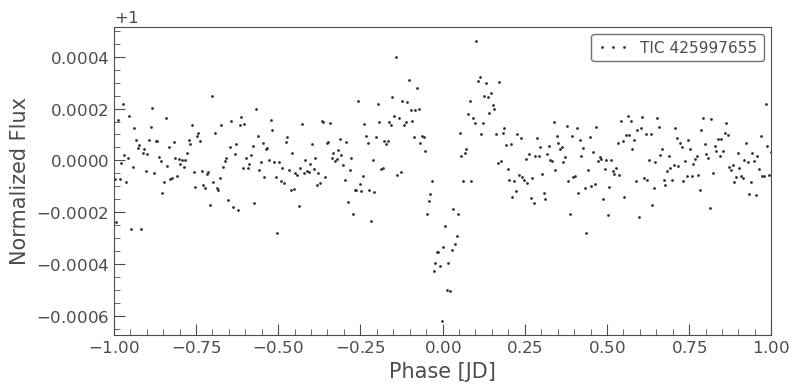

In [21]:
flc = combined_lc.fold(planet_1_period, planet_1_t0)
flc.bin(0.005,-1,1).plot(marker='.',lw=0)
plt.xlim(-1,1)
plt.show()


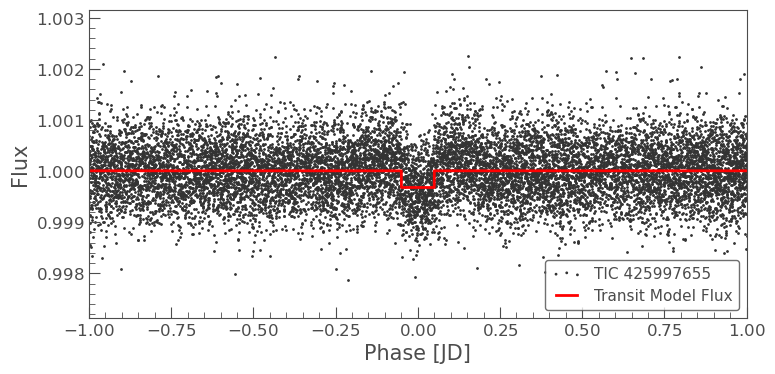

In [22]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 137484 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


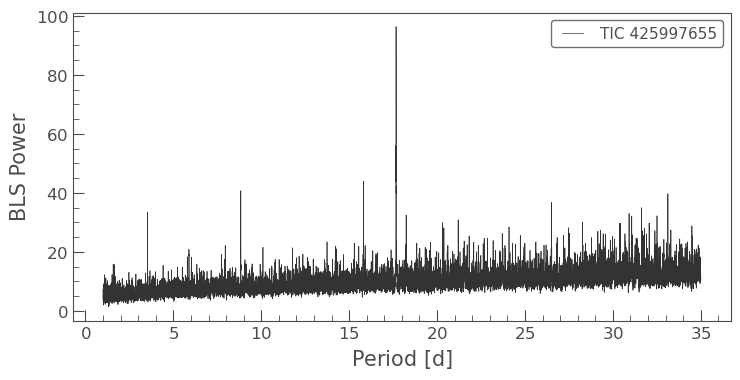

In [23]:
period = np.linspace(1, 35, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [24]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 17.66847 days
Best candidate t0 2: 1342.96158 days


In [25]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [26]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

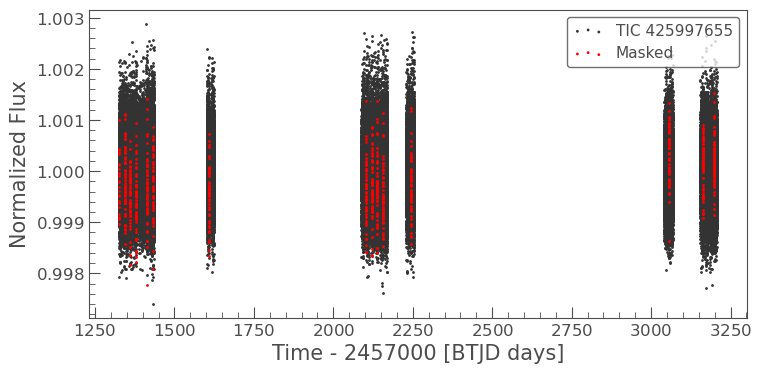

In [27]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [28]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

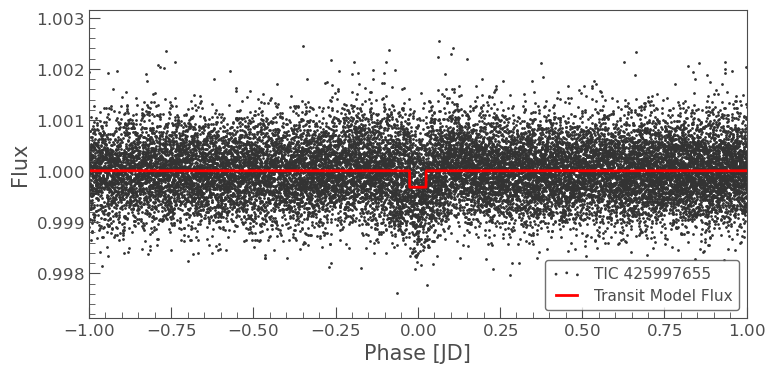

In [29]:
ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

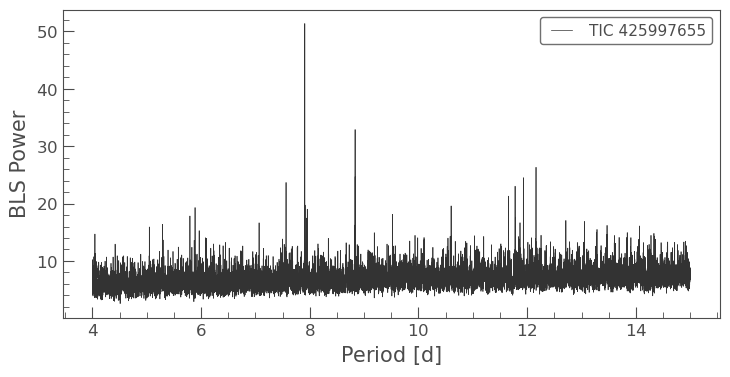

In [30]:
### start period search at 4days to try to find planet e before d
period = np.linspace(4, 15, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [31]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 7.90759 days
Best candidate t0 3: 1330.84631 days


In [32]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*1.5)


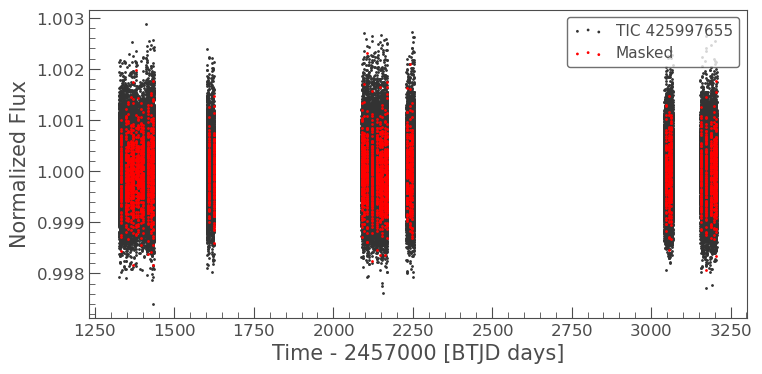

In [33]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [34]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

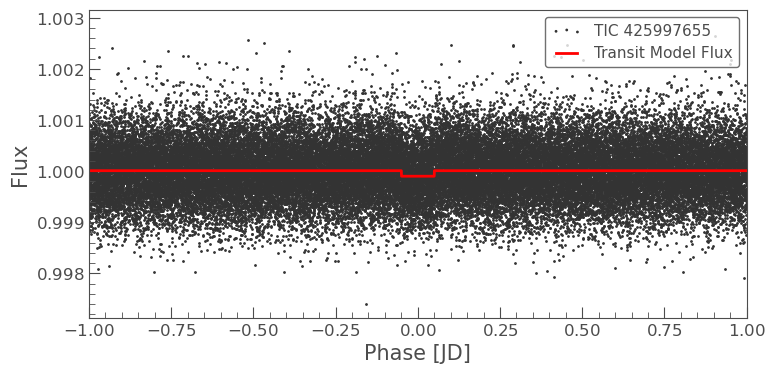

In [35]:
ax = masked_lc_2.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 4

`period` contains 132088 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


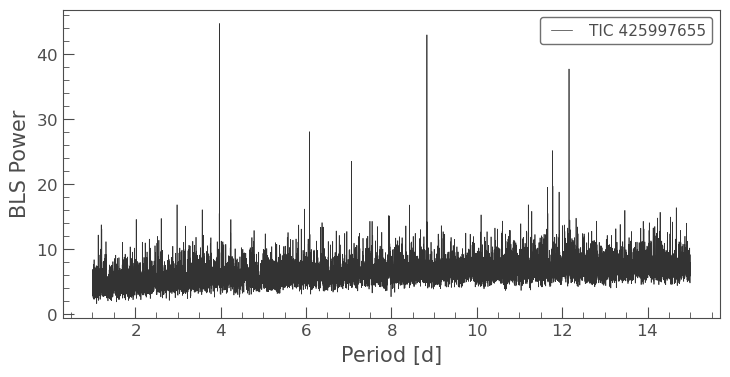

In [36]:
period = np.linspace(1, 15, 10000)
bls_4 = masked_lc_3.to_periodogram('bls', period=period, frequency_factor=500)
bls_4.plot()
plt.show()

In [37]:
planet_4_period = bls_4.period_at_max_power
planet_4_t0 = bls_4.transit_time_at_max_power
planet_4_dur = bls_4.duration_at_max_power

print(f"Best candidate period 4: {planet_4_period.value:.5f} days")
print(f"Best candidate t0 4: {planet_4_t0.value:.5f} days")

Best candidate period 4: 3.97670 days
Best candidate t0 4: 1326.02131 days


In [38]:
planet_4_mask = bls_4.get_transit_mask(period=planet_4_period,
                                     transit_time=planet_4_t0,
                                     duration=planet_4_dur*1.5)


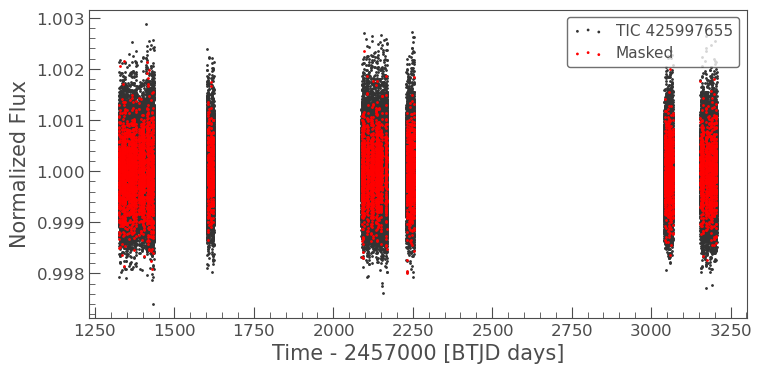

In [39]:
masked_lc_4 = masked_lc_3[~planet_4_mask]
ax = masked_lc_4.scatter();
masked_lc_3[planet_4_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [40]:
planet_4_model = bls_4.get_transit_model(period=planet_4_period,
                                       transit_time=planet_4_t0,
                                       duration=planet_4_dur)

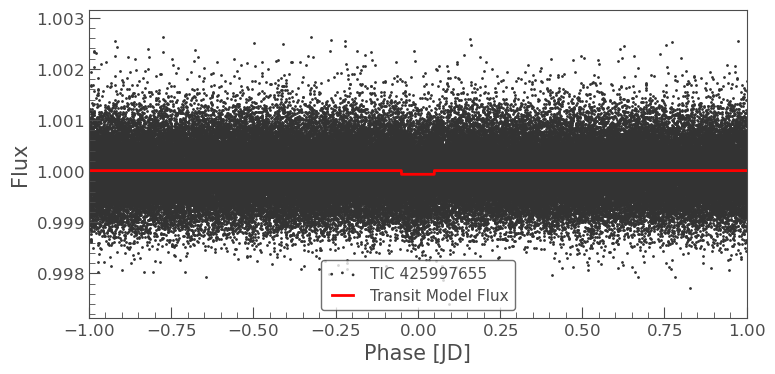

In [41]:
ax = masked_lc_3.fold(planet_4_period, planet_4_t0).scatter()
planet_4_model.fold(planet_4_period, planet_4_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 5

`period` contains 132088 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


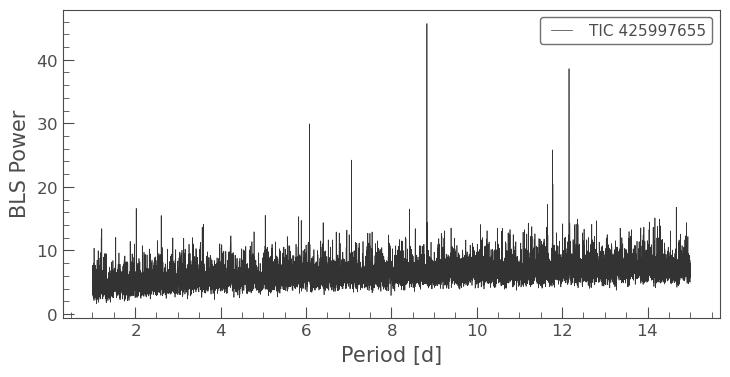

In [42]:
period = np.linspace(1, 15, 10000)
bls_5 = masked_lc_4.to_periodogram('bls', period=period, frequency_factor=500)
bls_5.plot()
plt.show()

In [43]:
planet_5_period = bls_5.period_at_max_power
planet_5_t0 = bls_5.transit_time_at_max_power
planet_5_dur = bls_5.duration_at_max_power

print(f"Best candidate period 5: {planet_5_period.value:.5f} days")
print(f"Best candidate t0 5: {planet_5_t0.value:.5f} days")

Best candidate period 5: 8.83378 days
Best candidate t0 5: 1334.13631 days


In [44]:
planet_5_mask = bls_5.get_transit_mask(period=planet_5_period,
                                     transit_time=planet_5_t0,
                                     duration=planet_5_dur*1.5)


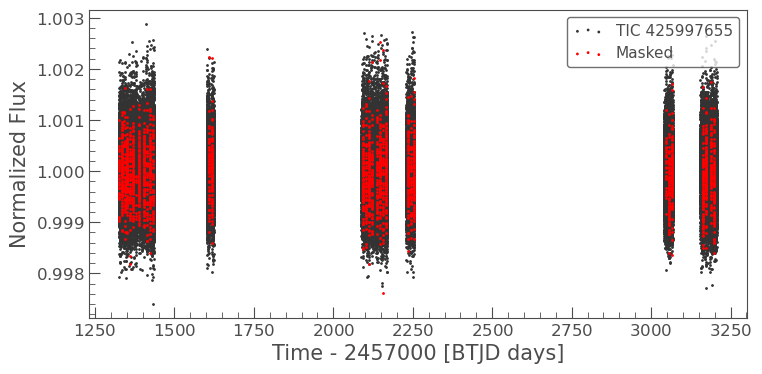

In [45]:
masked_lc_5 = masked_lc_4[~planet_5_mask]
ax = masked_lc_5.scatter();
masked_lc_4[planet_5_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [46]:
planet_5_model = bls_5.get_transit_model(period=planet_5_period,
                                       transit_time=planet_5_t0,
                                       duration=planet_5_dur)

## BLS 6

`period` contains 132081 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


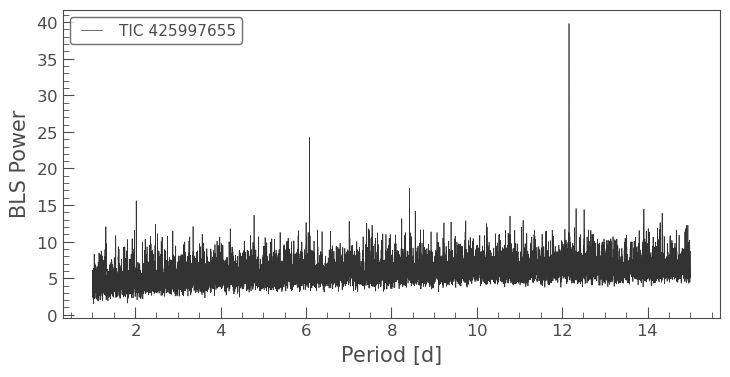

In [47]:
period = np.linspace(1, 15, 10000)
bls_6 = masked_lc_5.to_periodogram('bls', period=period, frequency_factor=500)
bls_6.plot()
plt.show()

In [48]:
planet_6_period = bls_6.period_at_max_power
planet_6_t0 = bls_6.transit_time_at_max_power
planet_6_dur = bls_6.duration_at_max_power

print(f"Best candidate period 6: {planet_6_period.value:.5f} days")
print(f"Best candidate t0 6: {planet_6_t0.value:.5f} days")

Best candidate period 6: 12.16192 days
Best candidate t0 6: 1335.76353 days


In [49]:
planet_6_mask = bls_6.get_transit_mask(period=planet_6_period,
                                     transit_time=planet_6_t0,
                                     duration=planet_6_dur*1.5)


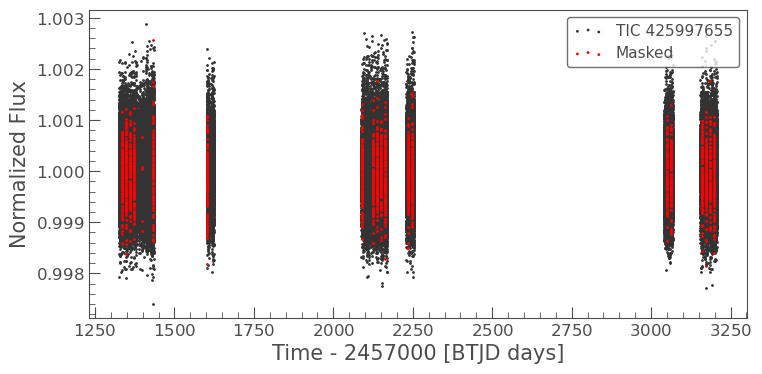

In [50]:
masked_lc_6 = masked_lc_5[~planet_6_mask]
ax = masked_lc_6.scatter();
masked_lc_5[planet_6_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [51]:
planet_6_model = bls_6.get_transit_model(period=planet_6_period,
                                       transit_time=planet_6_t0,
                                       duration=planet_6_dur)

## Transit models

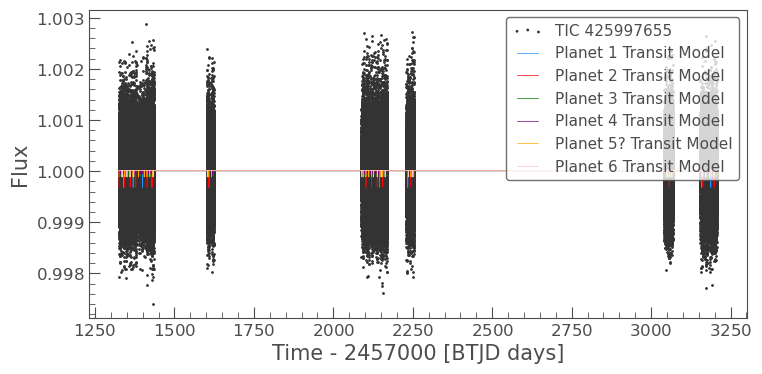

In [52]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [53]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = planet_1_model.time.value[peaks_1]
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_1, fluxes_1):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1340.3107512  1370.10829085 1399.90407569 1429.70088536 1608.48344476
 2144.82720741 2234.2167893  3157.92089369 3187.71714257]


In [54]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = planet_2_model.time.value[peaks_2]
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1342.96079611 1360.62906366 1378.29720847 1413.63448509 1431.3036323
 1607.98760338 2102.70520208 2120.37326059 2138.04256752 2155.71036274
 2244.05268787 3056.8020315  3162.81264689 3198.15053972]


In [55]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-6)
transit_times_3 = planet_3_model.time.value[peaks_3]
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_3, fluxes_3):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)
print(len(transit_times_3))

Planet 3 transit dip times and depths:
[1330.84531104 1346.66085312 1354.56788667 1362.47769046 1370.3832925
 1378.25415289 1386.19859181 1394.10689359 1402.01517038 1417.82887116
 1425.73706702 1433.64386244 1607.61120837 1623.42679324 2089.97456473
 2097.88156572 2105.78993726 2121.60519945 2137.42035292 2145.32720151
 2153.23540964 2161.14221044 2169.05037423 2232.31127857 2240.21803799
 2248.12621841 3046.79219925 3054.70060641 3062.60767221 3157.49866261
 3173.31420405 3189.12965234 3197.03664316 3204.94499503]
34


In [56]:
# Find all local minima (i.e., transit dips)
peaks_4, _ = find_peaks(-planet_4_model.flux.value, prominence=1e-6)
transit_times_4 = planet_4_model.time.value[peaks_4]
fluxes_4 = planet_4_model.flux.value[peaks_4]

print("Planet 4 transit dip times and depths:")
# for t, f in zip(transit_times_4, fluxes_4):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")

print(transit_times_4)
print(len(transit_times_4))

Planet 4 transit dip times and depths:
[1326.02021121 1329.99529415 1333.9745368  1337.9509921  1341.92883448
 1345.90389763 1349.88034057 1357.8345914  1361.8110184  1365.78743455
 1369.76384429 1373.74164238 1377.7180413  1389.64858363 1393.62634138
 1397.60131285 1401.57767401 1405.55541409 1413.50809779 1417.48720965
 1421.46075577 1425.43846095 1429.41477961 1433.39108997 1604.38893372
 1608.36260947 1616.31970527 1620.29617482 2089.5467824  2093.52320664
 2097.49961947 2105.45382523 2109.43021949 2117.38299102 2121.36075621
 2125.33712078 2133.28984124 2137.26757697 2141.24391368 2145.21192513
 2149.19659033 2153.14235579 2165.1046298  2169.12815018 2232.70710263
 2236.68478665 2240.66108369 2244.63739871 2248.61509761 2252.59140905
 3043.95467306 3047.93109792 3051.90752078 3055.88395993 3059.86041175
 3063.83685558 3067.81330081 3155.30138951 3159.27786484 3163.25432024
 3171.20861615 3175.21700635 3183.13792578 3187.11574884 3191.09216259
 3199.0449888  3203.02138588]
67


In [57]:
# Find all local minima (i.e., transit dips)
peaks_5, _ = find_peaks(-planet_5_model.flux.value, prominence=1e-6)
transit_times_5 = planet_5_model.time.value[peaks_5]
fluxes_5 = planet_5_model.flux.value[peaks_5]

print("Planet 5? transit dip times and depths:")
# for t, f in zip(transit_times_5, fluxes_5):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")

print(transit_times_5)
print(len(transit_times_5))

Planet 5? transit dip times and depths:
[1334.13565081 1343.00663019 1351.80536264 1360.67489741 1369.4707869
 1387.13886814 1404.80542203 1413.67754009 1422.47323709 1431.34529815
 1607.94593604 1616.81693756 2093.84126448 2102.64686838 2111.50938474
 2120.31492749 2137.98284604 2146.84384808 2155.65064168 2164.51158694
 2235.18204429 2243.99018907 2252.84973751 3047.84776387 3056.71869675
 3065.55771236 3162.72792337 3171.56278871 3189.24215303 3198.06442809]
30


In [58]:
# Find all local minima (i.e., transit dips)
peaks_6, _ = find_peaks(-planet_6_model.flux.value, prominence=1e-6)
transit_times_6 = planet_6_model.time.value[peaks_6]
fluxes_6 = planet_6_model.flux.value[peaks_6]

print("Planet 6? transit dip times and depths:")
# for t, f in zip(transit_times_6, fluxes_6):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")

print(transit_times_6)
print(len(transit_times_6))

Planet 6? transit dip times and depths:
[1335.763457   1347.9275375  1360.08600308 1372.24858033 1433.05776357
 1603.32502766 2089.80234071 2126.28711357 2138.44950685 2150.61184483
 2162.77273409 2235.74453102 2247.90677833 3050.59362046 3062.75489644
 3160.05010122 3172.21279902 3184.38933183 3196.53663894]
19


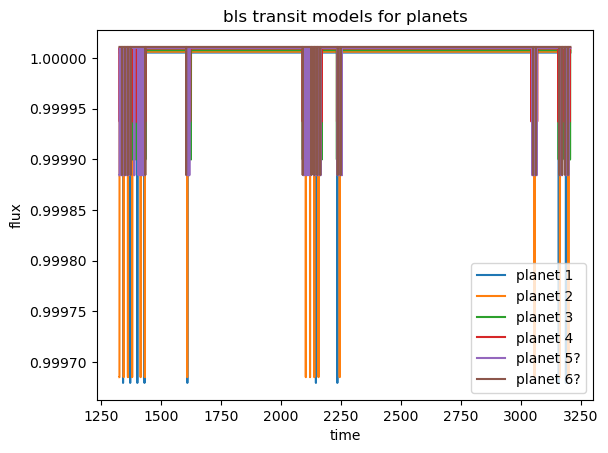

In [59]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [60]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [61]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [62]:
def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        ### fit parabola to the chisq
        p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        ### Extract the coefficients   y = ax^2 + bx + c
        a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        ### Calculate the minimum chi-squared value
        chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        tc_chi_parabola[j] = tc_best_fit
    
        ### Calculate the parabola best fit 
        p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        ### calculate ttv from parabola fit 
        ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # # Find the intersection using root_scalar
        # intersections = []
        # for k in range(len(tc1) - 1):
        #     if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections.append((sol.root - min_chi_time))
        # errors.append(intersections)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux
    
        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [104]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [65]:
### stellar params
u1 = 0.496 # p/m 0.051
u2 = 0.210 # p/m 0.052

## Planet 1

In [66]:
### Planet params (from barros et al 2022)
# planet c
per_1= 29.79749
rp_1= 0.0243
b_1= 0.785
T14_1= 2.94 * 0.0416667  # convert to days from hours


In [67]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [68]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []

In [69]:
# plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)
tc_chi_1, ttv_1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [70]:
print(tc_chi)

[1340.3018256  1370.10503759 1399.89515009 1429.69713161 1608.48352817
 2144.84464153 2234.23138725 3157.94433382 3187.74658871]


In [71]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi

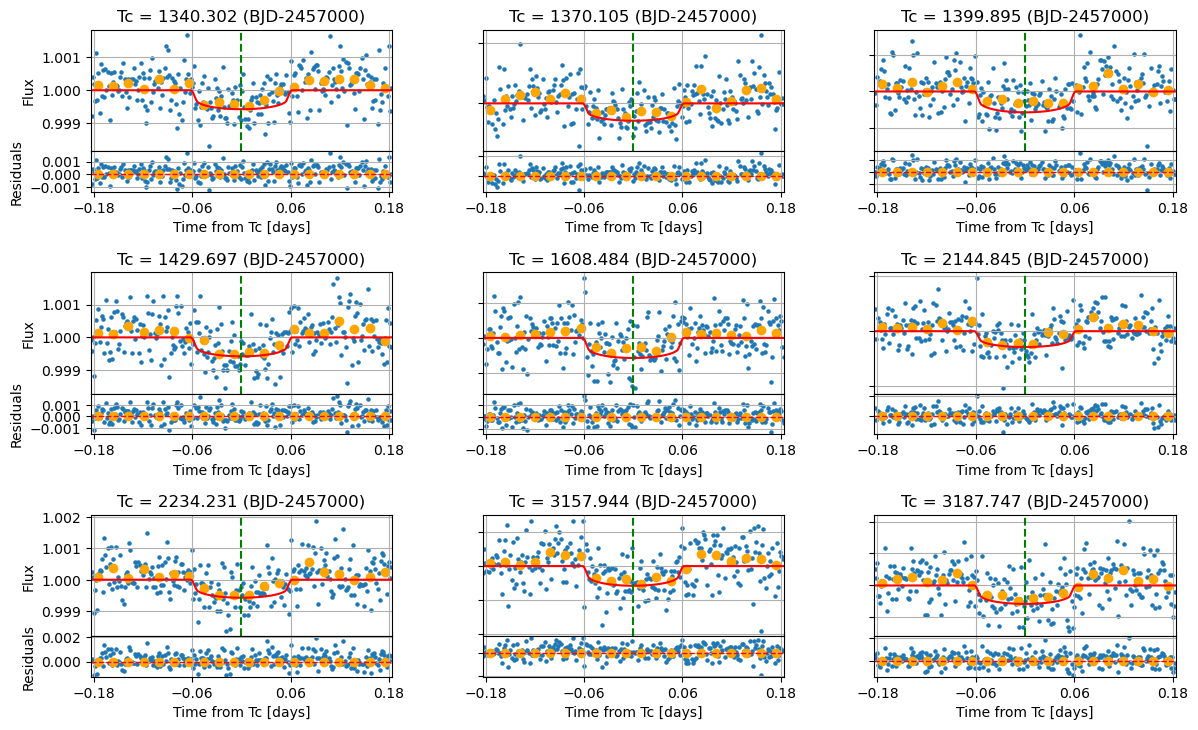

In [72]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

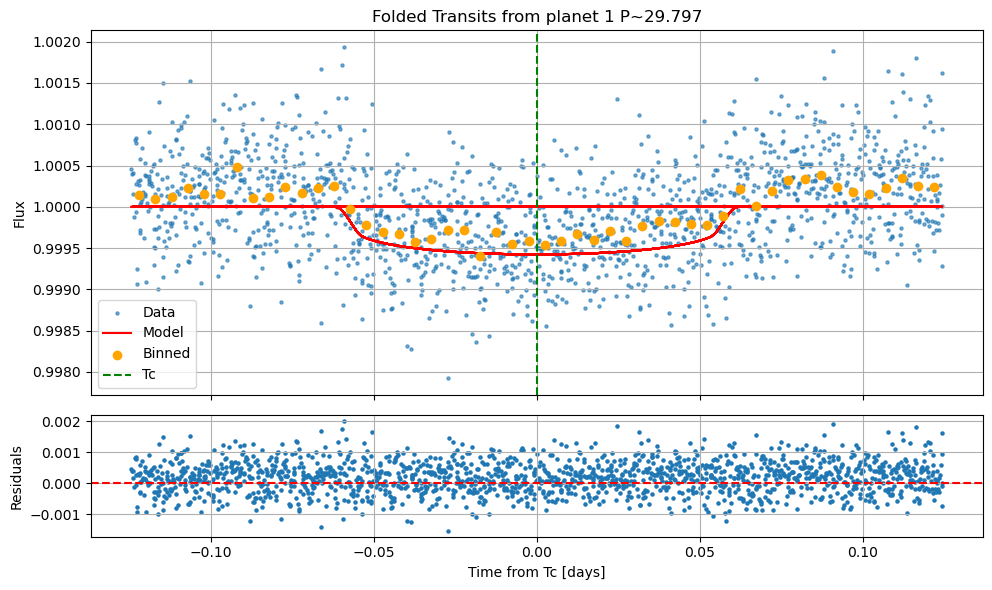

In [107]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [74]:
### Planet params (from barros et al 2022)
# planet b
per_2= 17.667087
rp_2= 0.02597
b_2= 0.690
T14_2= 2.67 * 0.0416667  # convert to days from hours


In [75]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - 6*ttv_hour
    end = tc_guess_2[i] + 6*ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [76]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []

In [77]:
# plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)
tc_chi_2, ttv_2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [78]:
print(tc_chi)

[1342.99232766 1360.66059522 1378.32773902 1413.67602666 1431.33416286
 1607.9951109  2102.68368055 2120.34273003 2138.01604097 2155.68183419
 2244.0141493  3056.70743683 3162.7040382  3198.03092   ]


In [79]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi

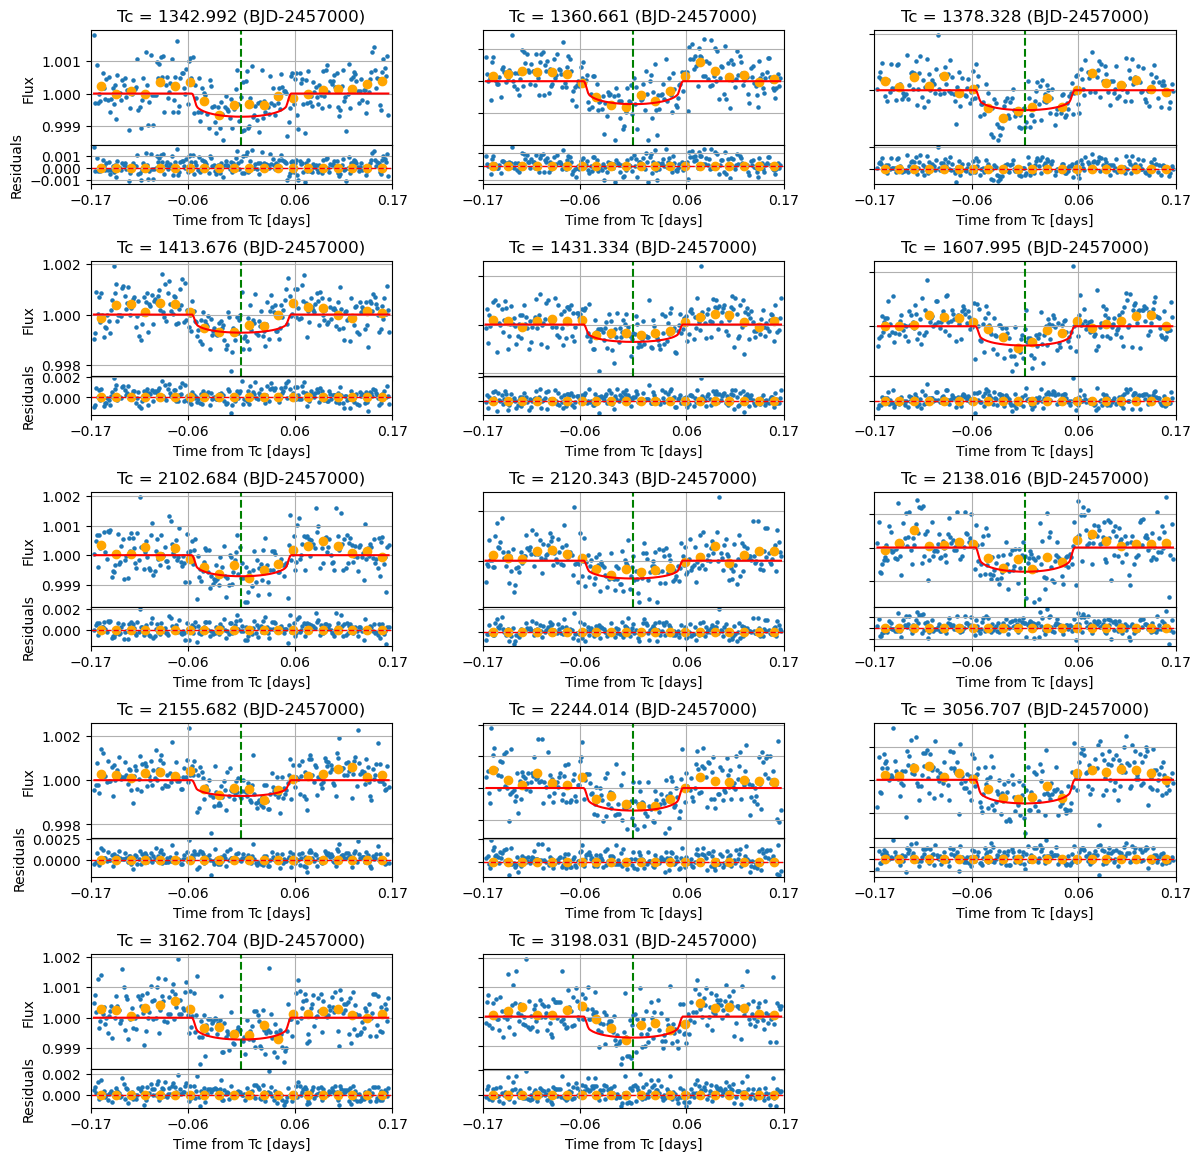

In [80]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

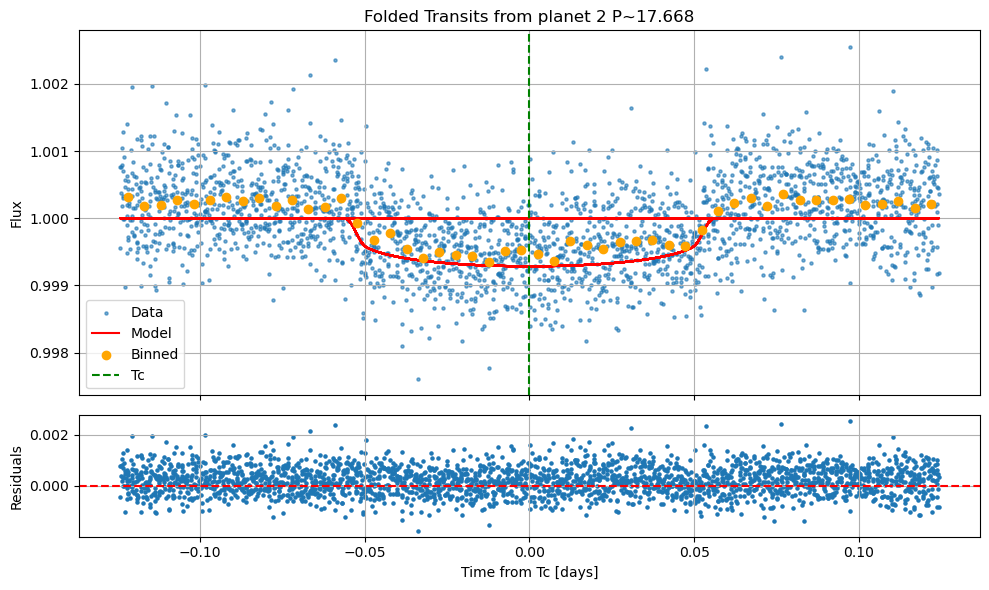

In [106]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

## Planet 3

In [82]:
### Planet params (from barros et al 2022)
# planet e
per_3= 7.90754
rp_3= 0.01065
b_3= 0.50
T14_3= 2.48 * 0.0416667  # convert to days from hours


In [83]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - 6*ttv_hour
    end = tc_guess_3[i] + 6*ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [84]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
tc_chi_parabola = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
ttv_p = np.zeros(len(tc_3))
errors = []
errors_p = []

In [85]:
# plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)
tc_chi_3, ttv_3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [86]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi
print(transit_times_3)

[1330.91588167 1346.64433659 1354.61343225 1362.51823103 1370.29970885
 1378.3157145  1386.30720051 1394.1103971  1402.01366887 1417.71225445
 1425.71754749 1433.62834691 1607.58868583 1623.41828472 2089.91000012
 2098.00819245 2105.77542273 2121.61570997 2137.42485743 2145.30768197
 2153.23691114 2161.1216899  2169.05287673 2232.4409083  2240.20952948
 2247.62621801 3046.72863563 3054.67808387 3062.48004448 3157.45612003
 3173.30569553 3189.14616887 3197.04014666 3204.90645646]


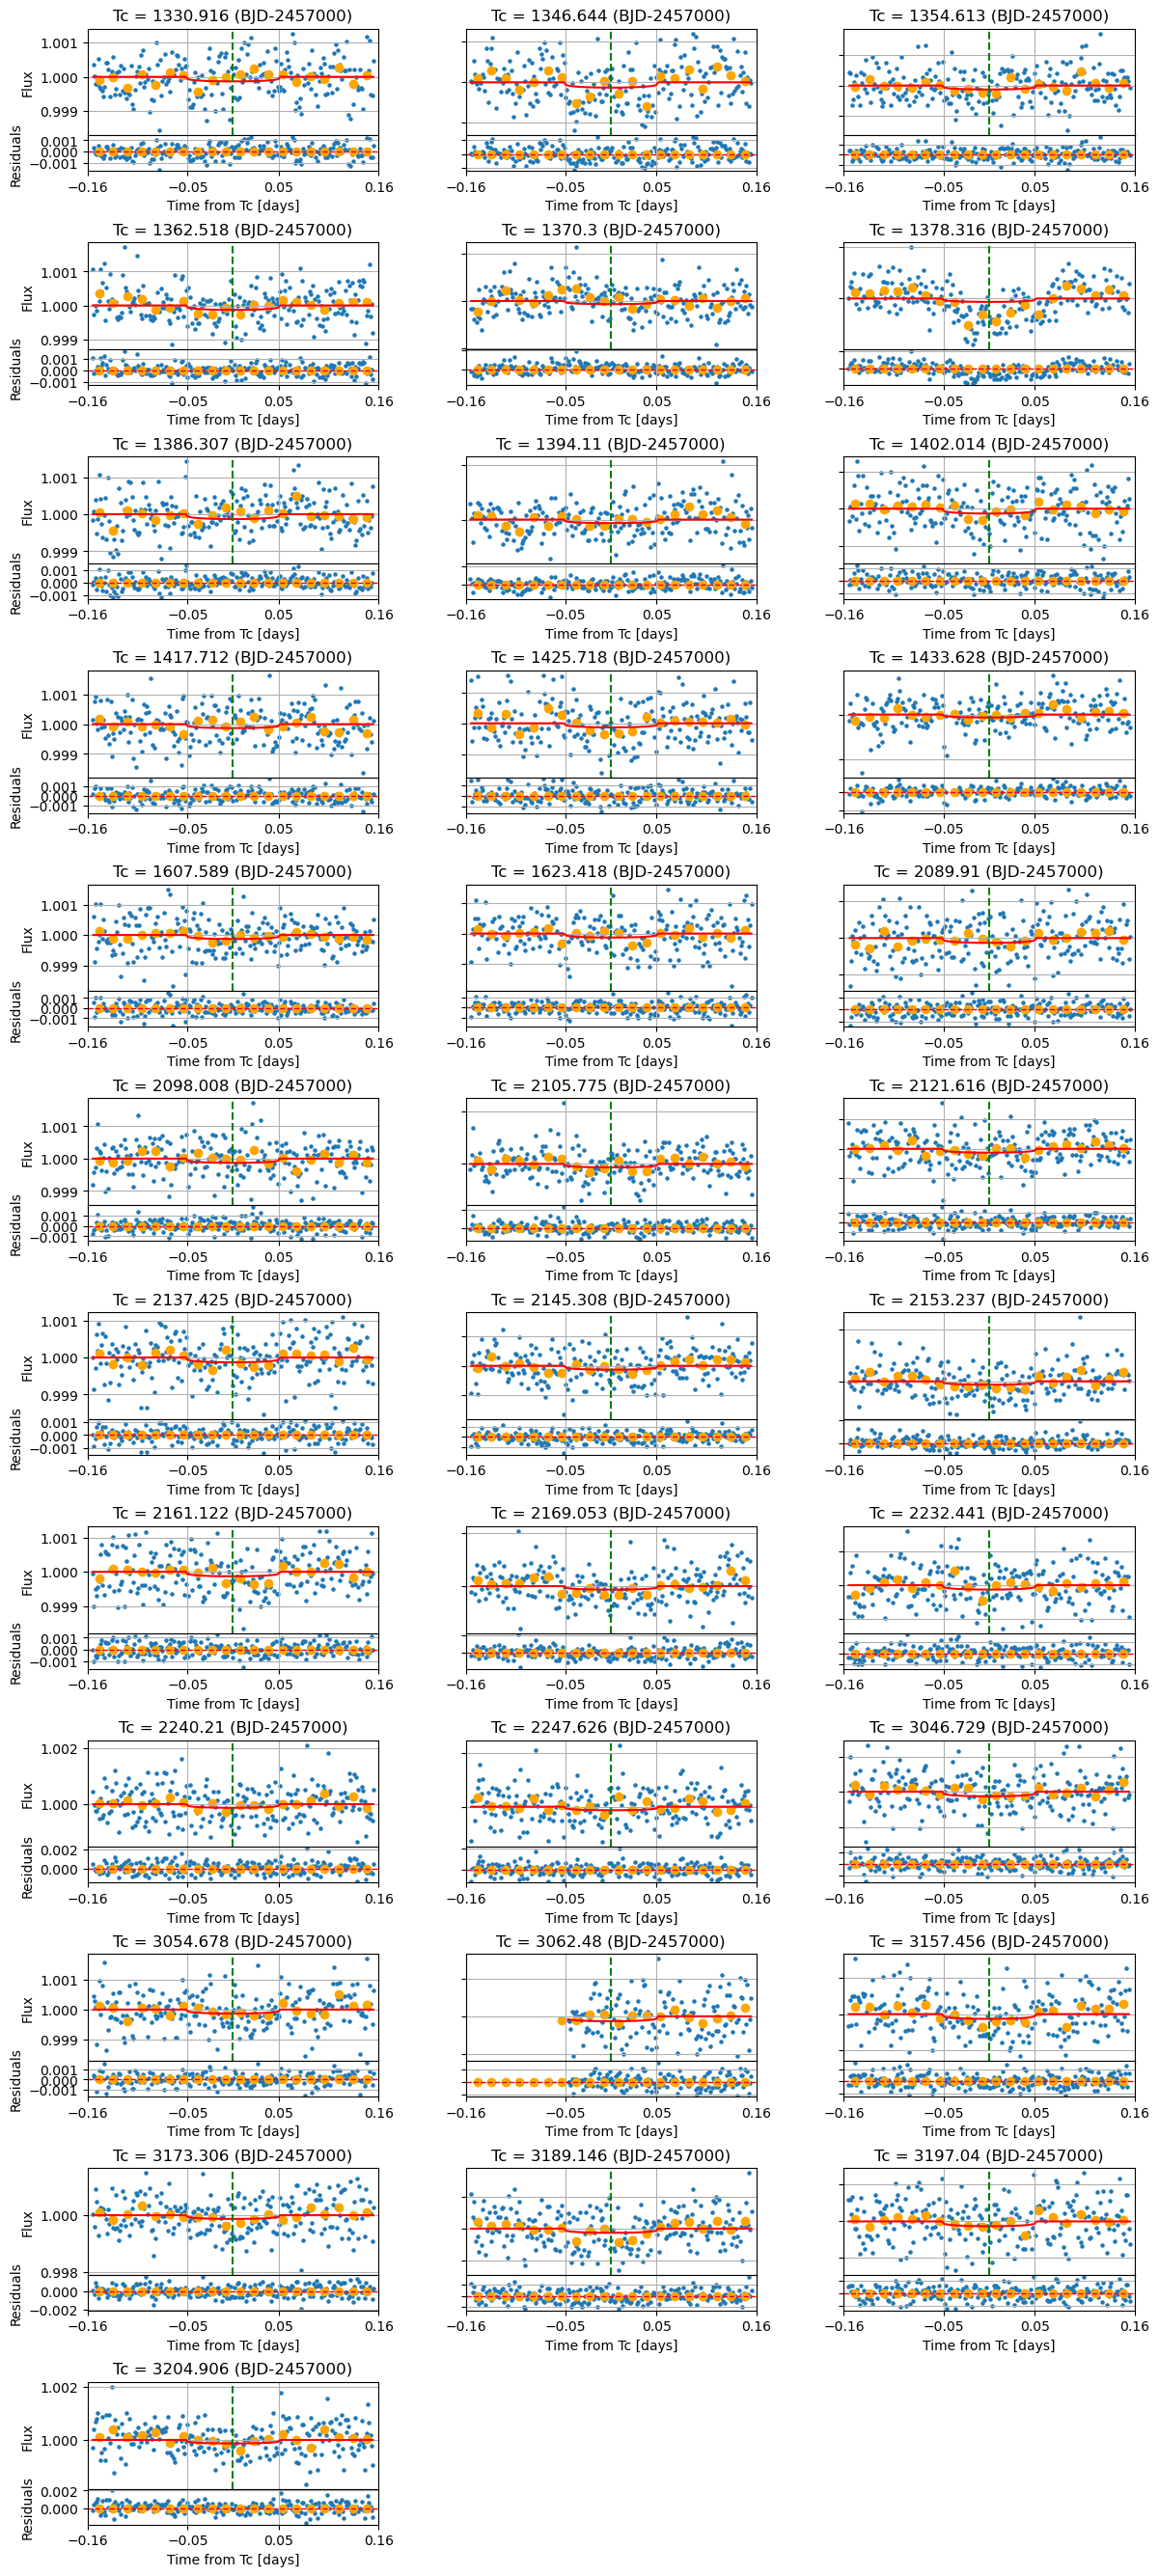

In [87]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

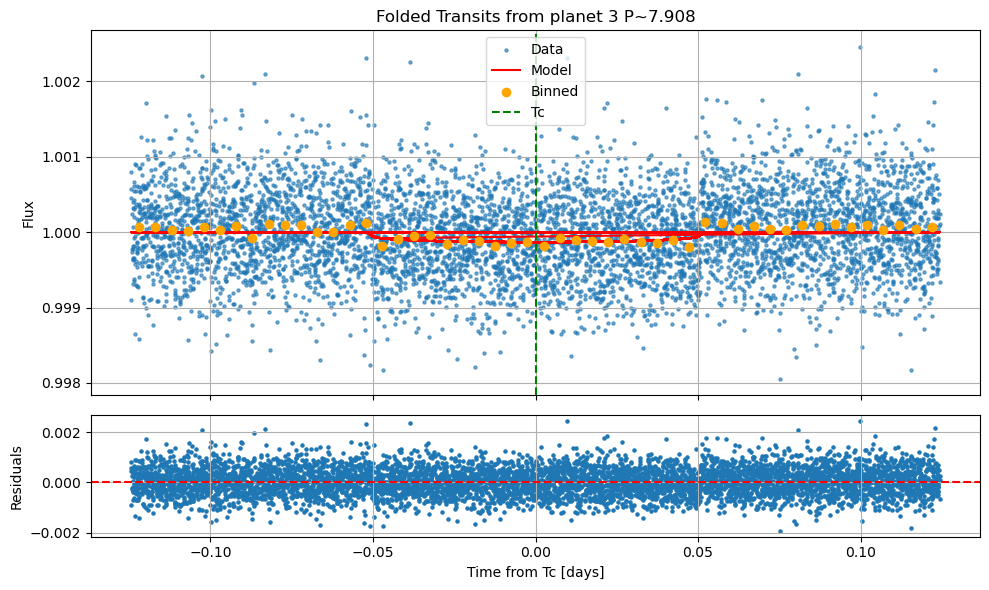

In [108]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 3 P~{round(planet_3_period.value, 3)}')

## Planet 4

In [89]:
### Planet params (from barros et al 2022)
# planet d
per_4= 3.97664
rp_4= 0.009752
b_4= 0.47
T14_4= 1.99 * 0.0416667  # convert to days from hours


In [90]:
tc_guess_4 = transit_times_4
### get tc ranges for fit
tc_4 = []
for i in range(len(tc_guess_4)):
    start = tc_guess_4[i] - ttv_hour
    end = tc_guess_4[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_4.append(t)

In [91]:
### initialize arrays
tc_chi = np.zeros(len(tc_4))
tc_chi_parabola = np.zeros(len(tc_4))
ttv = np.zeros(len(tc_4))
ttv_p = np.zeros(len(tc_4))
errors = []
errors_p = []

In [92]:
# plot_chi_sq(time, flux, flux_err, tc_4, tc_guess_4, per_4, rp_4, b_4, T14_4, u1, u2)
tc_chi_4, ttv_4 = plot_chi_sq(time, flux, flux_err, tc_4, tc_guess_4, per_4, rp_4, b_4, T14_4, u1, u2)

In [93]:
# Transit windows
buffer = 1.5 * T14_4
transit_times_4 = tc_chi
print(transit_times_4)

[1326.01345444 1329.91629843 1333.97862422 1337.93389165 1341.93559124
 1345.93884928 1349.87775465 1357.80464476 1361.8428002  1365.7653291
 1369.77060105 1373.76975385 1377.7086152  1389.63481986 1393.63159663
 1397.60773595 1401.59777746 1405.56133668 1413.48899534 1417.45375951
 1421.42063228 1425.41969216 1429.45373527 1433.39501056 1604.39185331
 1608.44594287 1616.39019248 1620.30343208 2089.53285179 2093.55632312
 2097.53590578 2105.47442918 2109.41795721 2117.37473276 2121.28609815
 2125.34104137 2133.37183997 2137.30069345 2141.26218196 2145.26172497
 2149.21769478 2153.21150833 2165.08352534 2169.06867399 2232.73221109
 2236.64699883 2240.64581841 2244.64549014 2248.59182432 2252.57397494
 3043.89936771 3047.97539225 3051.8932565  3055.83833094 3059.85315449
 3063.80240444 3067.82039124 3155.29329808 3159.28545577 3163.18650236
 3171.20686439 3175.1810537  3183.13217002 3187.10031673 3191.14463176
 3199.01387433 3202.96057502]


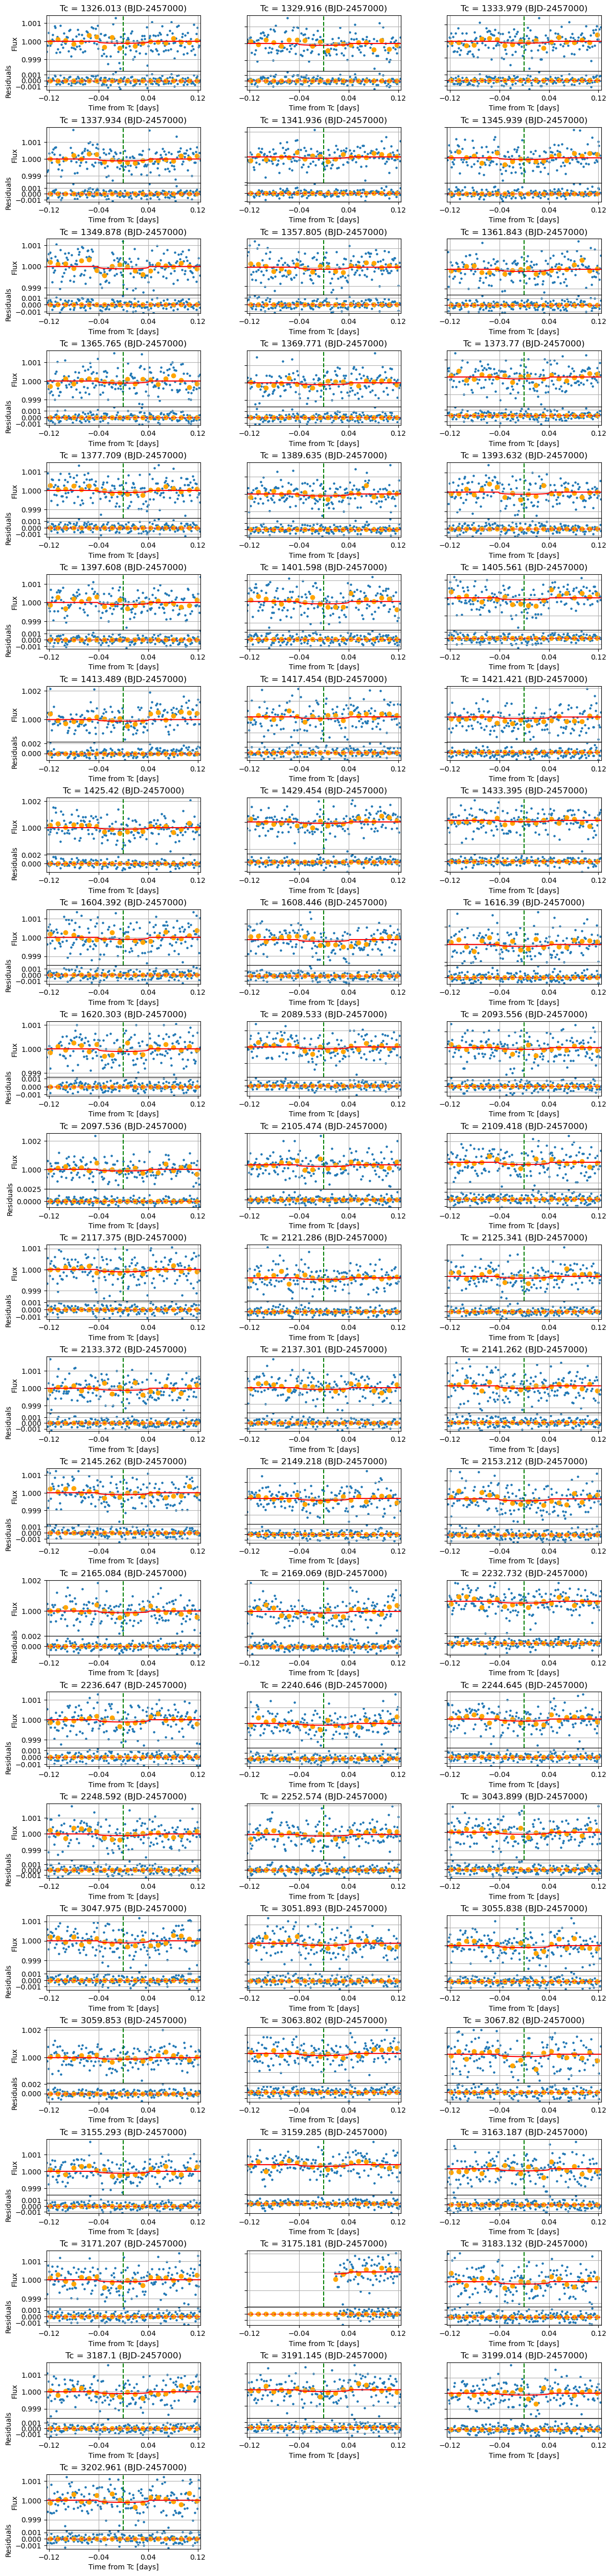

In [94]:
plot_transits(transit_times_4, per_4, rp_4, b_4, T14_4, u1, u2)

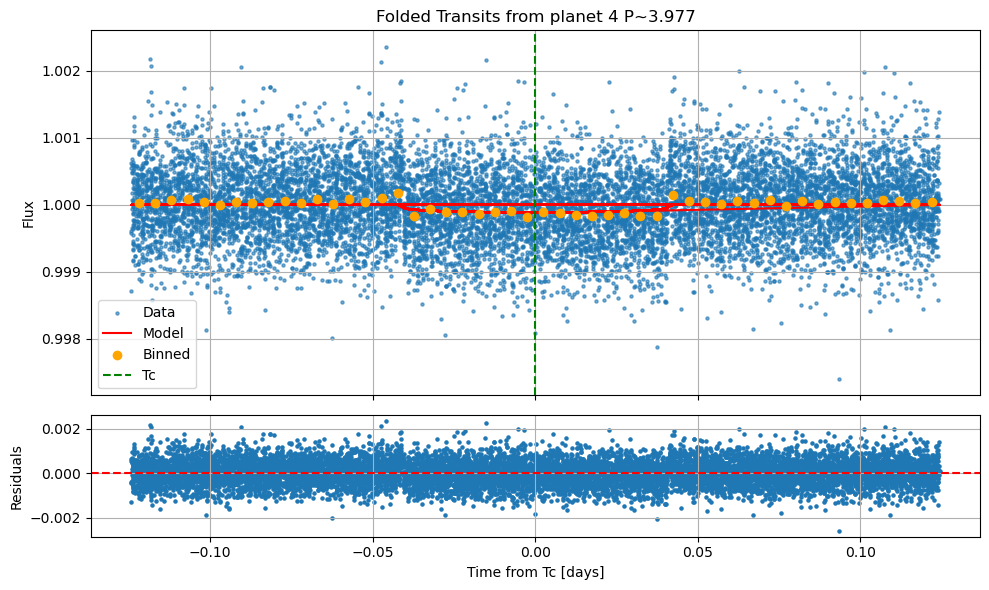

In [109]:
plot_folded_from_transits(transit_times_4, time, flux, per_4, rp_4, b_4, T14_4, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 4 P~{round(planet_4_period.value, 3)}')

## O-C

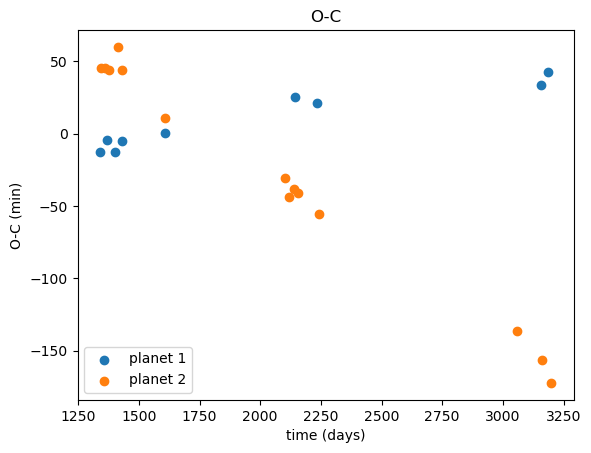

In [96]:
# TTV
plt.scatter(tc_chi_1, ttv_1*(24*60), label='planet 1')
plt.scatter(tc_chi_2, ttv_2*(24*60), label='planet 2')
plt.title('O-C')
plt.xlabel('time (days)')
plt.ylabel('O-C (min)')
plt.legend()
plt.show()

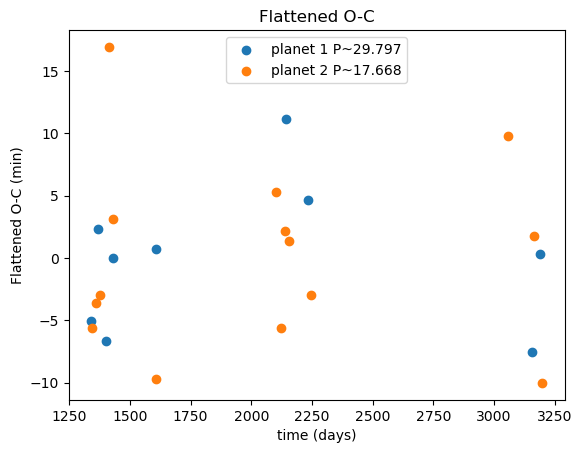

In [97]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2

# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended, label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended, label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend(loc='upper center')
plt.show()

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_1_minutes = ttv_1 * 24 * 60

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_1_minutes), .1, planet_1_period.value, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_1, ttv_1_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit = np.linspace(min(tc_chi_1), max(tc_chi_1), 1000)
ttv_fit = model(t_fit, a, b, A, P, phi)

# # Plot data and fit
# plt.scatter(tc_chi_1, ttv_1_minutes, label='planet 1 data')
# plt.plot(t_fit, ttv_fit, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# # Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_2_minutes = ttv_2 * 24 * 60

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_2_minutes), .01, planet_2_period.value, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_2, ttv_2_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
ttv_fit_2 = model(t_fit, a, b, A, P, phi)

# Plot data and fit
# plt.scatter(tc_chi_2, ttv_2_minutes, label='planet 1 data')
# plt.plot(t_fit_2, ttv_fit_2, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


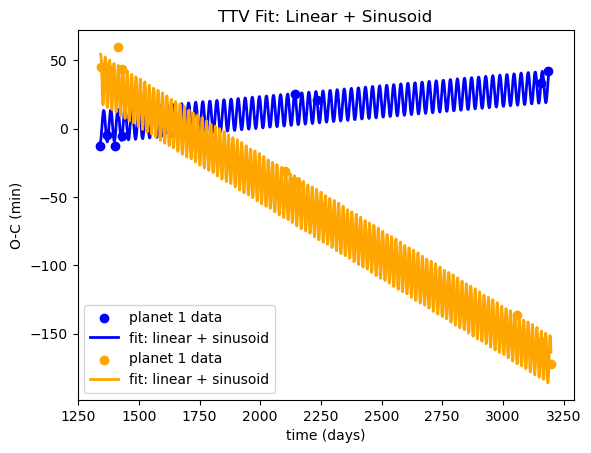

In [100]:
# Plot data and fit
plt.scatter(tc_chi_1, ttv_1_minutes, c='blue',label='planet 1 data')
plt.plot(t_fit, ttv_fit, color='blue', label='fit: linear + sinusoid', linewidth=2)

# Plot data and fit
plt.scatter(tc_chi_2, ttv_2_minutes,c='orange', label='planet 1 data')
plt.plot(t_fit_2, ttv_fit_2, color='orange', label='fit: linear + sinusoid', linewidth=2)
plt.title('TTV Fit: Linear + Sinusoid')
plt.xlabel('time (days)')
plt.ylabel('O-C (min)')
plt.legend()
plt.show()

### planets 3 and 4 (resonant pair)

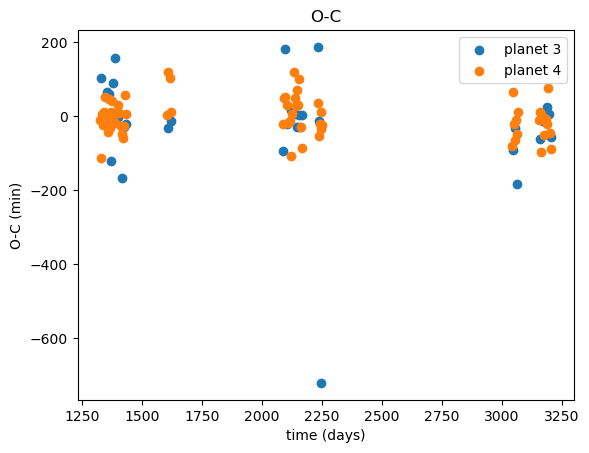

In [101]:
# TTV
plt.scatter(tc_chi_3, ttv_3*(24*60), label='planet 3')
plt.scatter(tc_chi_4, ttv_4*(24*60), label='planet 4')
plt.title('O-C')
plt.xlabel('time (days)')
plt.ylabel('O-C (min)')
plt.legend()
plt.show()

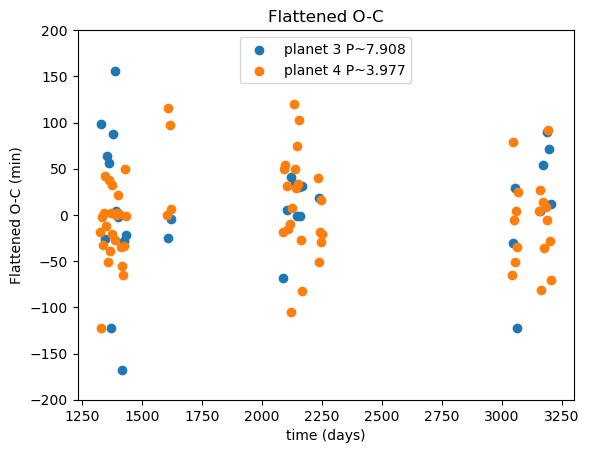

In [110]:
# Fit a linear function to the TTV data
coeffs_3 = np.polyfit(tc_chi_3, ttv_3*(24*60), 1)
linear_fit_3 = np.polyval(coeffs_3, tc_chi_3)

coeffs_4 = np.polyfit(tc_chi_4, ttv_4*(24*60), 1)
linear_fit_4 = np.polyval(coeffs_4, tc_chi_4)

# Subtract the linear fit from the TTV data
ttv_3_detrended = ttv_3*(24*60) - linear_fit_3
ttv_4_detrended = ttv_4*(24*60) - linear_fit_4

# Plot the detrended data
plt.scatter(tc_chi_3, ttv_3_detrended, label=f'planet 3 P~{round(planet_3_period.value,3)}')
plt.scatter(tc_chi_4, ttv_4_detrended, label=f'planet 4 P~{round(planet_4_period.value,3)}')
plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.ylim(-200,200)
plt.legend(loc='upper center')
plt.show()